# Task 1 - Bishal
What is the average age of players who appeared in the FIFA World Cup 2026, and does the average age differ between players from teams that reached the knockout stage and those that did not?

1. Import libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

2. Import the dataset

In [ ]:
df = pd.read_csv("task-1-data.csv")
df.head()

,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,1.eng Leeds United,2000,1,1,76,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,5bc43860
1,2,Thelo Aasgaard,MF,no Norway,24,1.sct Rangers,2002,1,1,90,...,0,0,0,1.0,0.0,1.0,1.0,1.0,Matches,c88a28b9
2,3,Hamza Abdelkarim,FW,eg Egypt,18,4.es Barcelona B,2008,4,0,60,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,057d8f12
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,1.eg Zamalek SC,2001,2,0,59,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,accbfc94
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1.fr Nice,1999,2,1,14,...,0,0,0,0.0,0.0,0.0,0.0,0.0,Matches,bff15d74


3. Understanding the dataset

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(df.columns.tolist())

df.info()

df.describe()

print("Unique players:", df["Player"].nunique())
print("Unique squads:", df["Squad"].nunique())

df["Squad"].value_counts().sort_index()

df["MP"].value_counts().sort_index()
print("Players with at least one appearance:",
      (df["MP"] > 0).sum())

Rows: 1039
Columns: 26
['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Club', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK', 'Matches', '-9999']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rk       1039 non-null   int64  
 1   Player   1039 non-null   object 
 2   Pos      1039 non-null   object 
 3   Squad    1039 non-null   object 
 4   Age      1039 non-null   int64  
 5   Club     1036 non-null   object 
 6   Born     1039 non-null   int64  
 7   MP       1039 non-null   int64  
 8   Starts   1039 non-null   int64  
 9   Min      1039 non-null   int64  
 10  90s      1039 non-null   float64
 11  Gls      1039 non-null   int64  
 12  Ast      1039 non-null   int64  
 13  G+A      1039 non-null   int64  
 14  G-PK     1039 non-null   int64  
 15  PK    

4. Since whether team reached the knockout or not is missing from the dataset. We are manually adding this data to the df.

In [8]:
knockout_teams = [
    'us USA',
    'no Norway',
    'eg Egypt',
    'za South Africa',
    "ci Côte d'Ivoire",
    'gh Ghana',
    'ch Switzerland',
    'ca Canada',
    'dz Algeria',
    'nl Netherlands',
    'fr France',
    'at Austria',
    'ba Bosnia–Herz',
    'ec Ecuador',
    'py Paraguay',
    'se Sweden',
    'br Brazil',
    'ar Argentina',
    'mx Mexico',
    'ma Morocco',
    'de Germany',
    'eng England',
    'pt Portugal',
    'cv Cabo Verde',
    'co Colombia',
    'es Spain',
    'cd Congo DR',
    'hr Croatia',
    'au Australia',
    'sn Senegal',
    'be Belgium',
    'jp Japan'
]
df["KnockoutStage"] = df["Squad"].isin(knockout_teams)
df.head()
df["KnockoutStage"].value_counts()
df.groupby("KnockoutStage")["Squad"].nunique()
df.head(10)

,Rk,Player,Pos,Squad,Age,Club,Born,MP,Starts,Min,...,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Matches,-9999,KnockoutStage
0,1,Brenden Aaronson,MF,us USA,25,1.eng Leeds United,2000,1,1,76,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,5bc43860,True
1,2,Thelo Aasgaard,MF,no Norway,24,1.sct Rangers,2002,1,1,90,...,0,0,1.0,0.0,1.0,1.0,1.0,Matches,c88a28b9,True
2,3,Hamza Abdelkarim,FW,eg Egypt,18,4.es Barcelona B,2008,4,0,60,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,057d8f12,True
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,1.eg Zamalek SC,2001,2,0,59,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,accbfc94,True
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1.fr Nice,1999,2,1,14,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,bff15d74,True
5,6,Ali Abdi,DF,tn Tunisia,32,1.fr Nice,1993,3,3,269,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,ad7cdb35,False
6,7,Saud Abdulhamid,DF,sa Saudi Arabia,26,1.fr Lens,1999,3,3,269,...,1,0,0.0,0.0,0.0,0.0,0.0,Matches,caa254e4,False
7,8,Abdulla Abdullaev,DF,uz Uzbekistan,28,1.ae Dibba Al Fujairah,1997,2,2,180,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,03053fbf,False
8,9,Yusuf Abdurisag,FW,qa Qatar,26,1.qa Al-Wakrah,1999,2,2,98,...,0,0,0.0,0.0,0.0,0.0,0.0,Matches,13c8f40b,False
9,10,Husam Abu Dahab,DF,jo Jordan,26,1.kw Al-Salmiya SC,2000,2,2,178,...,1,0,0.0,0.0,0.0,0.0,0.0,Matches,300aaeb6,False


4. Create our analytical dataset

In [9]:
# remove players who never appeared.
players = df[df["MP"] > 0].copy()

5. Check for duplicate players

In [10]:
duplicate_players = players[players.duplicated("Player", keep=False)]

duplicate_players[["Player", "Squad", "Age", "MP"]].sort_values("Player")

,Player,Squad,Age,MP


Check the age variable

count    1039.000000
mean       27.463908
std         4.198173
min        17.000000
25%        24.000000
50%        27.000000
75%        30.000000
max        41.000000
Name: Age, dtype: float64
Missing ages: 0


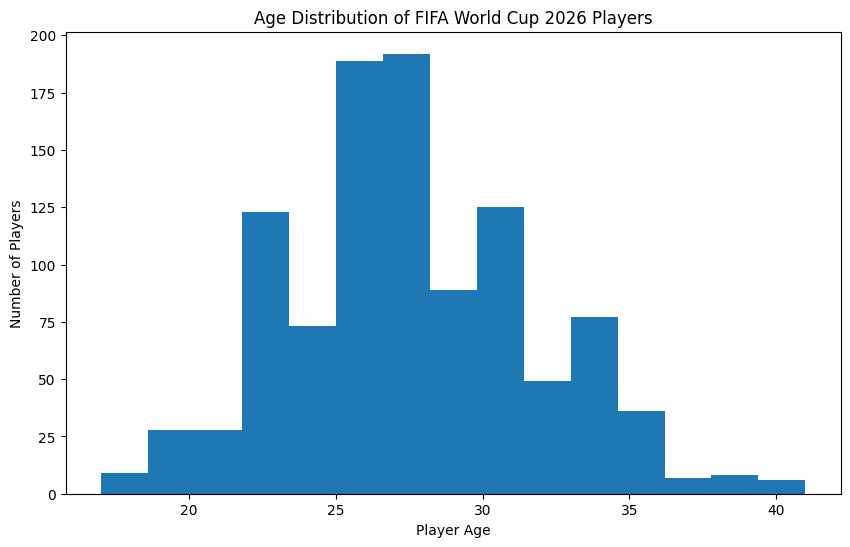

In [11]:
print(players["Age"].describe())
print("Missing ages:", players["Age"].isna().sum())

plt.figure(figsize=(10, 6))

plt.hist(players["Age"], bins=15)

plt.xlabel("Player Age")
plt.ylabel("Number of Players")
plt.title("Age Distribution of FIFA World Cup 2026 Players")

plt.show()

Create the final analytical dataset

In [12]:
analysis_df = players[
    ["Player", "Squad", "Age", "MP", "KnockoutStage"]
].copy()
analysis_df.head(10)

,Player,Squad,Age,MP,KnockoutStage
0,Brenden Aaronson,us USA,25,1,True
1,Thelo Aasgaard,no Norway,24,1,True
2,Hamza Abdelkarim,eg Egypt,18,4,True
3,Hossam Abdelmaguid,eg Egypt,25,2,True
4,Mohamed Abdelmonem,eg Egypt,27,2,True
5,Ali Abdi,tn Tunisia,32,3,False
6,Saud Abdulhamid,sa Saudi Arabia,26,3,False
7,Abdulla Abdullaev,uz Uzbekistan,28,2,False
8,Yusuf Abdurisag,qa Qatar,26,2,False
9,Husam Abu Dahab,jo Jordan,26,2,False


In [13]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Player         1039 non-null   object
 1   Squad          1039 non-null   object
 2   Age            1039 non-null   int64 
 3   MP             1039 non-null   int64 
 4   KnockoutStage  1039 non-null   bool  
dtypes: bool(1), int64(2), object(2)
memory usage: 33.6+ KB


Overall descriptive statistics

In [14]:
overall_stats = analysis_df["Age"].describe()

print(overall_stats)

count    1039.000000
mean       27.463908
std         4.198173
min        17.000000
25%        24.000000
50%        27.000000
75%        30.000000
max        41.000000
Name: Age, dtype: float64


In [15]:
mean_age = analysis_df["Age"].mean()

print(f"Average player age: {mean_age:.2f} years")

Average player age: 27.46 years


Compare the two groups

In [22]:
knockout_players = analysis_df[
    analysis_df["KnockoutStage"] == True
]
non_knockout_players = analysis_df[
    analysis_df["KnockoutStage"] == False
]

print("Knockout players:", len(knockout_players))
print("Non-knockout players:", len(non_knockout_players))

knockout_players["Age"].describe()

Knockout players: 713
Non-knockout players: 326


,Age
count,713.000000
mean,27.193548
std,4.269912
min,17.000000
25%,24.000000
50%,27.000000
75%,30.000000
max,41.000000


In [23]:
non_knockout_players["Age"].describe()

,Age
count,326.000000
mean,28.055215
std,3.979566
min,18.000000
25%,25.000000
50%,28.000000
75%,31.000000
max,39.000000


Comparision table

In [24]:
comparison = pd.DataFrame({
    "Knockout Stage": knockout_players["Age"].describe(),
    "Did Not Reach Knockout": non_knockout_players["Age"].describe()
})

comparison

knockout_mean = knockout_players["Age"].mean()
non_knockout_mean = non_knockout_players["Age"].mean()

print(f"Knockout-stage teams: {knockout_mean:.2f} years")
print(f"Non-knockout teams: {non_knockout_mean:.2f} years")

difference = knockout_mean - non_knockout_mean

print(f"Difference in average age: {difference:.2f} years")

Knockout-stage teams: 27.19 years
Non-knockout teams: 28.06 years
Difference in average age: -0.86 years


Visualization

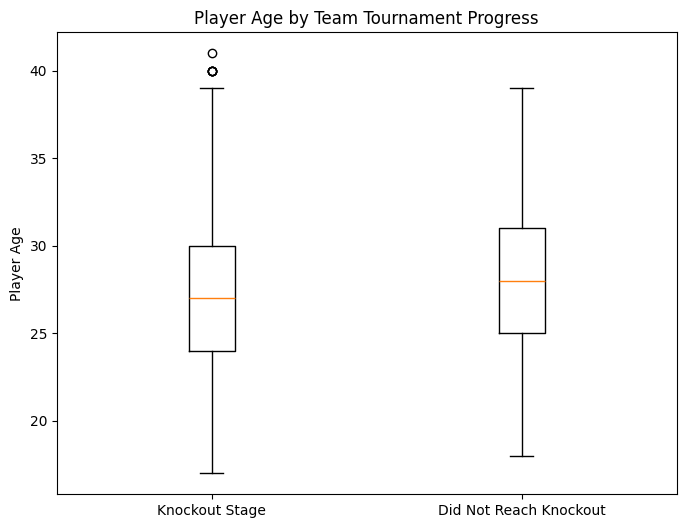

In [25]:
plt.figure(figsize=(8, 6))

plt.boxplot([
    knockout_players["Age"],
    non_knockout_players["Age"]
])

plt.xticks(
    [1, 2],
    ["Knockout Stage", "Did Not Reach Knockout"]
)

plt.ylabel("Player Age")
plt.title("Player Age by Team Tournament Progress")

plt.show()

Calculate the 95% confidence interval

In [26]:
ages = analysis_df["Age"].dropna()

n = len(ages)
mean = ages.mean()
std = ages.std()

confidence_level = 0.95
degrees_of_freedom = n - 1

t_critical = stats.t.ppf(
    (1 + confidence_level) / 2,
    degrees_of_freedom
)

margin_of_error = t_critical * (std / np.sqrt(n))

lower = mean - margin_of_error
upper = mean + margin_of_error

print(f"Mean age: {mean:.2f}")
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

Mean age: 27.46
95% Confidence Interval: (27.21, 27.72)


Confidence intervals for both groups

In [28]:
def confidence_interval(data, confidence=0.95):
    data = data.dropna()

    n = len(data)
    mean = data.mean()
    std = data.std()

    standard_error = std / np.sqrt(n)

    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        n - 1
    )

    margin_of_error = t_critical * standard_error

    lower = mean - margin_of_error
    upper = mean + margin_of_error

    return mean, lower, upper

In [29]:
knockout_ci = confidence_interval(
    knockout_players["Age"]
)

non_knockout_ci = confidence_interval(
    non_knockout_players["Age"]
)

print("Knockout-stage teams:")
print(f"Mean: {knockout_ci[0]:.2f}")
print(f"95% CI: {knockout_ci[1]:.2f} - {knockout_ci[2]:.2f}")

print()

print("Non-knockout teams:")
print(f"Mean: {non_knockout_ci[0]:.2f}")
print(f"95% CI: {non_knockout_ci[1]:.2f} - {non_knockout_ci[2]:.2f}")

Knockout-stage teams:
Mean: 27.19
95% CI: 26.88 - 27.51

Non-knockout teams:
Mean: 28.06
95% CI: 27.62 - 28.49


Two-sample t-test

In [30]:
t_statistic, p_value = stats.ttest_ind(
    knockout_players["Age"],
    non_knockout_players["Age"],
    equal_var=False
)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: -3.1643
p-value: 0.0016


Interpret the t-test

In [31]:
# Set our significance level:
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence that the average ages differ.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that the average ages differ.")


Reject the null hypothesis.
There is statistically significant evidence that the average ages differ.


Final summary table

In [32]:
summary = pd.DataFrame({
    "Group": [
        "All players",
        "Knockout-stage teams",
        "Non-knockout teams"
    ],
    "Sample Size": [
        len(analysis_df),
        len(knockout_players),
        len(non_knockout_players)
    ],
    "Mean Age": [
        analysis_df["Age"].mean(),
        knockout_players["Age"].mean(),
        non_knockout_players["Age"].mean()
    ],
    "Median Age": [
        analysis_df["Age"].median(),
        knockout_players["Age"].median(),
        non_knockout_players["Age"].median()
    ],
    "Standard Deviation": [
        analysis_df["Age"].std(),
        knockout_players["Age"].std(),
        non_knockout_players["Age"].std()
    ]
})

summary

,Group,Sample Size,Mean Age,Median Age,Standard Deviation
0,All players,1039,27.463908,27.0,4.198173
1,Knockout-stage teams,713,27.193548,27.0,4.269912
2,Non-knockout teams,326,28.055215,28.0,3.979566
